# Winner Prediction for U.S. Thoroughbred Racing

**A neural-network system that predicts each horse's probability of winning a race, using only information available before post time.**

| | |
|---|---|
| **Objective** | Predict the win probability of every horse entered in a U.S. Thoroughbred race, from information known before the race starts. |
| **Primary KPI** | Top-ranked horse win rate (% of races where the model's highest-probability horse wins) |
| **Secondary KPIs** | Betting ROI, Log Loss, NDCG@3, Top-3 hit rate |
| **Success criteria** | Top-rank win rate ≥ 35% (vs. a ~30% favorite baseline); Log Loss better (relative) than a logistic-regression baseline; increase in top-rank win rate over the favorite baseline by any amount |
| **Users** | Handicappers, bettors, racing analysts, researchers |
| **Decisions supported** | Which horse to select as the likely winner; whether a horse is undervalued relative to the public odds |

### Why machine learning
A horse's chance of winning depends on non-linear interactions between its own form, its jockey and trainer, the
race conditions, and the strength of the field it's facing. A simple rule ("bet the horse with the best 
speed figure in its last race" or "bet the morning-line favorite") ignores those interactions and produces a heuristic ranking
rather than a calibrated probability. The benchmark uses that simplest rule-based approach (the
morning-line favorite) as **Baseline 1** below, and the machine learning algorithms show what learning from thousands of historical races buys
us on top of it.

### Constraints
- Predictions must be produced before official post time, using only pre-race information.
- Inference must be fast enough to score a full 8–12 race card in under a second (a few hundred rows through a
  small MLP — trivially satisfied; verified in the inference-latency check near the end of this notebook).
- TIdeally, this entire notebook, including parsing ~230k historical
  race entries from raw XML, runs end-to-end on a single CPU laptop in well under 30 minutes.

## Data sources

| | |
|---|---|
| **Dataset** | Equibase 2023 Free Dataset — Past Performances & Result Charts |
| **Provider** | Equibase Company LLC |
| **Files used** | `2023 PPs.zip` (pre-race entry/past-performance files, `SIMDyyyymmddTRK_CTR.xml` schema), `2023 Result Charts.zip` (post-race result charts, `TRKyyyymmddtch.xml` schema), `Equibase Parameters.xlsx` (code dictionaries, incl. the authoritative Country/Track-code/State table used for geographic filtering) |
| **Version** | 2023 calendar-year release |
| **Acquisition** | Downloaded XML archives, sent directly to me by Equibase. |
| **License note** | Free dataset provided by Equibase for academic use. |

Result Charts are the *primary source of data*: for every race already run, they record
the official finish, running line, speed figure, final odds, and payouts. We use them for (a) the label and (b)
—critically—as the sole source of every horse's/jockey's/trainer's **historical** performance record, computed
with a strict "no peeking at today" rule (details in the Leakage Prevention section). Past-Performance (PP)
files are the pre-race entry files; Result Charts don't carry pre-race market information, so PP files are used
for exactly one thing: each horse's **morning-line odds** for its upcoming race.

In [1]:
import os, re, io, zipfile, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import etl, features, models, evaluation

PROJECT_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

PARAMS_XLSX = r'C:\Users\zmaje\Downloads\Equibase Dataset\Equibase Parameters.xlsx'
CHARTS_ZIP  = r'C:\Users\zmaje\Downloads\Equibase Dataset\2023 Result Charts.zip'
PP_ZIP      = r'C:\Users\zmaje\Downloads\Equibase Dataset\2023 PPs.zip'

# --- dataviz palette (validated categorical set; see project's dataviz skill) ---
CAT = {'blue': '#2a78d6', 'aqua': '#1baf7a', 'yellow': '#eda100', 'green': '#008300',
       'violet': '#4a3aa7', 'red': '#e34948', 'magenta': '#e87ba4', 'orange': '#eb6834'}
INK, MUTED, GRID = '#0b0b0b', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
    'axes.labelcolor': INK, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'font.size': 11, 'figure.dpi': 100,
})

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print('Working directory:', PROJECT_DIR)

Working directory: C:\Users\zmaje\HorseRacingNN


## Unit, time, and output

- **Unit of analysis**: one horse entered in one race (one row per horse-race pair).
- **Prediction time**: immediately before post time, using only official entries, past performance history,
  announced track condition, and morning-line odds.
- **Prediction horizon**: from ~1–5 minutes before post to the official result, realized within ~1–3 minutes
  after the race starts.
- **Target**: `Y = 1` if the horse is the official winner (post-DQ), else `0`. Secondary output: a per-horse
  ranking score (its predicted win probability) used to rank the full field.
- **Task type**: primary — binary classification (win / not win); secondary — ranking (order the field by
  predicted win probability; evaluated with NDCG@3 and top-3 hit rate).

## Filtering: U.S. Thoroughbred races only

Two filters are applied before any XML content is parsed for modeling:

1. **Thoroughbred only** — every `RACE` element in a Result Chart carries a `BREED` code; we keep `TB` only
   (drops Quarter Horse / Arabian / mixed cards that occasionally share a track's daily card).
2. **Located in one of the 50 U.S. states** — the Equibase Parameters workbook's *Track codes* sheet gives an
   authoritative `Country Code` for every track. We build the USA track-code set from rows where
   `Country Code == 'USA'` (208 tracks, each with a real 2-letter state abbreviation).

Result Chart filenames (`TRKyyyymmddtch.xml`) don't carry a country code, so we recover the track code from the
filename and look it up in that table; PP filenames (`SIMDyyyymmddTRK_CTR.zip`) already carry the country code
directly.

In [2]:
usa_track_map = etl.load_usa_track_map(PARAMS_XLSX)
print(f'USA (50-state) track codes recognized: {len(usa_track_map)}')

zf = zipfile.ZipFile(CHARTS_ZIP)
chart_names = [n for n in zf.namelist() if n.lower().endswith('tch.xml')]
codes_seen = {}
for n in chart_names:
    m = etl.CHART_NAME_RE.match(n.split('/')[-1])
    if m:
        codes_seen[m.group(1).upper()] = codes_seen.get(m.group(1).upper(), 0) + 1
n_usa_files = sum(v for k, v in codes_seen.items() if k in usa_track_map)
n_dropped = sum(v for k, v in codes_seen.items() if k not in usa_track_map)
print(f'Result Chart files found: {len(chart_names)}')
print(f'  -> kept (USA, 50-state track): {n_usa_files}')
print(f'  -> dropped (Canada / Puerto Rico track): {n_dropped}')

USA (50-state) track codes recognized: 208
Result Chart files found: 4906
  -> kept (USA, 50-state track): 4314
  -> dropped (Canada / Puerto Rico track): 592


## Parsing the raw XML into a horse-race table

`etl.py` (in this project folder) implements the parsers described above. It reads every Result Chart and PP
file **directly out of the zip archives** (no bulk extraction to disk) with `lxml`, applies the Thoroughbred +
USA filters race-by-race, and returns one row per horse-race entry.

Every column pulled out of a chart is tagged at the source:
- **pre-race facts** (post position, weight, equipment, medication, jockey/trainer assignment, claiming price,
  race conditions) — safe to use as a feature of the row's own race.
- **post-race outcomes** (`post_official_fin`, `post_speed_rating`, `post_final_call_*`, `post_finish_time`,
  `post_dollar_odds`, `post_win_payoff`) — prefixed `post_` and **never** used as a feature of the row's own
  race. They are only ever used as *history* for a later race (see the Leakage Prevention section next).

This cell runs the full parse (~4,300 Result Chart files + ~4,700 PP files) fresh from the raw archives.

In [3]:
t0 = time.time()
chart_df = etl.build_chart_table(CHARTS_ZIP, usa_track_map)
print(f'chart_df: {chart_df.shape[0]:,} horse-race entries across '
      f'{chart_df.groupby(["date","track_code","race_number"]).ngroups:,} races  '
      f'({time.time()-t0:.0f}s)')
chart_df.to_parquet(os.path.join(DATA_DIR, 'chart_entries.parquet'), index=False)

  ...1000/4906 chart files scanned, 52686 entry-rows so far


  ...2000/4906 chart files scanned, 101991 entry-rows so far


  ...3000/4906 chart files scanned, 148082 entry-rows so far


  ...4000/4906 chart files scanned, 194735 entry-rows so far


Chart files parsed: 4314, skipped (non-USA track): 592, failed: 0


chart_df: 235,965 horse-race entries across 31,746 races  (24s)


In [4]:
t0 = time.time()
pp_df = etl.build_pp_table(PP_ZIP, usa_track_map)
print(f'pp_df: {pp_df.shape[0]:,} starter-rows (morning-line odds source)  ({time.time()-t0:.0f}s)')
pp_df.to_parquet(os.path.join(DATA_DIR, 'pp_morning_lines.parquet'), index=False)

  ...500/5919 PP files scanned, 35619 starter-rows so far


  ...1000/5919 PP files scanned, 71349 starter-rows so far


  ...1500/5919 PP files scanned, 106254 starter-rows so far


  ...2000/5919 PP files scanned, 139731 starter-rows so far


  ...2500/5919 PP files scanned, 170690 starter-rows so far


...

  ...4000/5919 PP files scanned, 265944 starter-rows so far


  ...4500/5919 PP files scanned, 297741 starter-rows so far


  ...5500/5919 PP files scanned, 358903 starter-rows so far


PP files parsed: 4698, skipped (non-USA track): 1221, failed: 0


pp_df: 384,744 starter-rows (morning-line odds source)  (360s)


In [5]:
print('Date range:', chart_df['date'].min().date(), '->', chart_df['date'].max().date())
print()
print('Race class breakdown:')
print(chart_df['race_class'].value_counts())
print()
print('Field-size distribution (horses per race):')
print(chart_df.groupby(['date','track_code','race_number'])['horse_name'].count().describe())
print()
print(f"Overall win rate (sanity check, should be close to 1/avg field size): {chart_df['post_official_fin'].eq(1).mean():.1%}")

Date range: 2023-01-01 -> 2023-12-31

Race class breakdown:
race_class
Claiming                 87095
Maiden Claiming          35536
Maiden Special Weight    35132
Allowance                25499
Optional Claiming        20957
Starter Allowance        17498
Stakes                   14104
Other                      144
Name: count, dtype: int64

Field-size distribution (horses per race):
count    31746.000000
mean         7.432905
std          1.861325
min          2.000000
25%          6.000000
50%          7.000000
75%          9.000000
max         18.000000
Name: horse_name, dtype: float64

Overall win rate (sanity check, should be close to 1/avg field size): 13.5%


## Exploratory data analysis

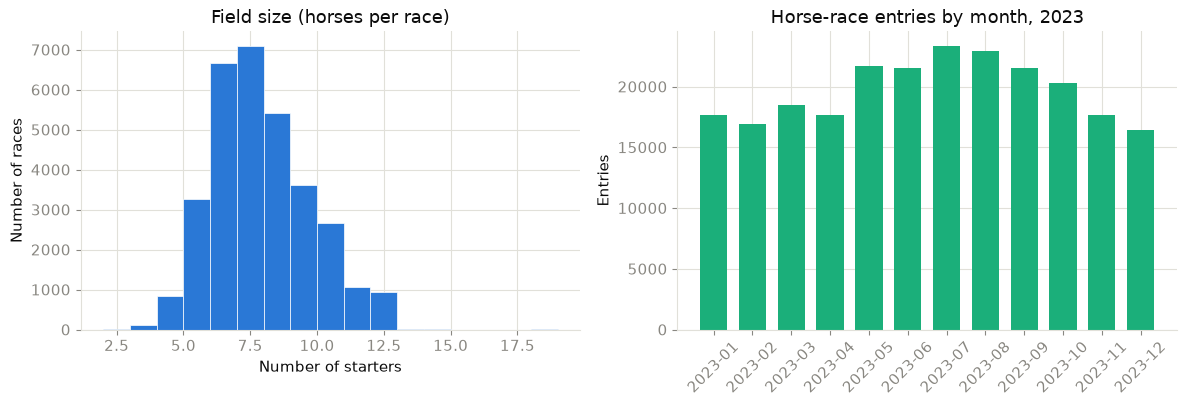

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

field_sizes = chart_df.groupby(['date','track_code','race_number'])['horse_name'].count()
axes[0].hist(field_sizes, bins=range(2, 20), color=CAT['blue'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Field size (horses per race)')
axes[0].set_xlabel('Number of starters')
axes[0].set_ylabel('Number of races')

monthly = chart_df.groupby(chart_df['date'].dt.to_period('M')).size()
axes[1].bar(monthly.index.astype(str), monthly.values, color=CAT['aqua'], width=0.7)
axes[1].set_title('Horse-race entries by month, 2023')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Entries')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

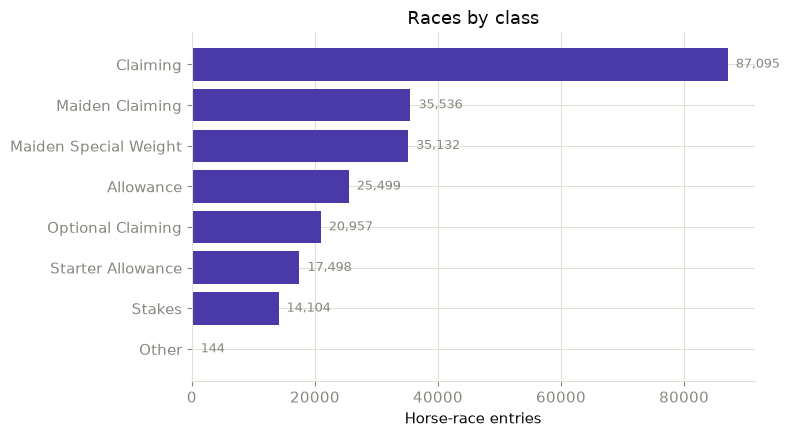

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
rc = chart_df['race_class'].value_counts().sort_values()
ax.barh(rc.index, rc.values, color=CAT['violet'])
ax.set_title('Races by class')
ax.set_xlabel('Horse-race entries')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(rc.values):
    ax.text(v, i, f'  {v:,}', va='center', color=MUTED, fontsize=9)
plt.tight_layout()
plt.show()

## Leakage prevention

Two leakage paths were called out in the task framing, and both are addressed directly:

**Leakage Path 1 — using future races in a horse's own statistics.** `features.py` sorts every horse's (and
every jockey's, and every trainer's) rows chronologically, then computes every historical aggregate — win %,
in-the-money %, average recent speed figure, days since last race, horse×surface/distance/track suitability,
jockey and trainer win rates — as an **expanding window over `.shift(1)`**: the aggregate for row *t* only ever
sees rows strictly before *t*. A debut horse (`horse_prior_starts == 0`) has no history yet, by construction —
it is not silently backfilled from its own future starts.

**Leakage Path 2 — random train/test splitting.** We do **not** use `train_test_split`. The split is
chronological by calendar date (next section), so a horse's later-season form can never leak backward into an
earlier-season training fold.

**Column-level discipline.** `post_dollar_odds` (final tote odds) and `post_win_payoff` are excluded from the
feature set entirely — the only odds feature used for prediction is `morning_line_decimal_odds`, sourced from
the pre-race PP file. `post_official_fin`, `post_speed_rating`, `post_final_call_*`, and `post_finish_time` are
likewise excluded as features of a horse's own race; they are only ever read as *history* for that horse's next
start.

In [8]:
t0 = time.time()
feat = features.build_feature_table(chart_df, pp_df)
print(f'feature_table: {feat.shape[0]:,} rows x {feat.shape[1]} columns  ({time.time()-t0:.0f}s)')
print(f"Morning-line odds coverage: {feat['morning_line_decimal_odds'].notna().mean():.1%} of entries")
feat.to_parquet(os.path.join(DATA_DIR, 'feature_table.parquet'), index=False)

feature_table: 235,965 rows x 74 columns  (162s)
Morning-line odds coverage: 99.2% of entries


### Feature list

| Group | Features |
|---|---|
| Race conditions (pre-race) | purse, distance (furlongs), sprint/route bucket, class rating, field size, track condition, surface, race class |
| Entry conditions (pre-race) | post position, weight carried, age, sex, medication, equipment, claiming price |
| Market (pre-race) | morning-line decimal odds, morning-line implied probability |
| Horse history (`.shift(1)` expanding) | prior starts, win %, in-the-money %, avg speed fig (last 3 / last 5), lifetime-best speed fig, avg finish (last 5), days since last race, debut flag, horse×surface / ×distance-bucket / ×track win % |
| Jockey history | prior mounts, win %, in-the-money %, win % (last 50 mounts) |
| Trainer history | prior starts, win %, win % (last 50 starts) |
| Trainer-horse combo | prior starts and prior wins for this specific trainer/horse pairing |

In [9]:
missing = feat[features.PRE_RACE_FEATURE_COLUMNS].isna().mean().sort_values(ascending=False)
print('Missingness among pre-race features (top 10, mostly first-time-starter / first-time-at-X cases):')
print((missing.head(10) * 100).round(1).astype(str) + '%')

Missingness among pre-race features (top 10, mostly first-time-starter / first-time-at-X cases):
horse_track_win_pct           39.9%
equip                         32.4%
trainer_horse_prior_wins      25.9%
horse_distbucket_win_pct      25.0%
horse_surface_win_pct         23.5%
horse_avg_finish_last5        18.1%
horse_best_speed_lifetime     18.1%
horse_days_since_last_race    18.1%
horse_avg_speed_last5         18.1%
horse_itm_pct                 18.1%
dtype: str


## Time-based train / validation / test split

| Split | Window | Share |
|---|---|---|
| Train | Jan 1 – Aug 31, 2023 | ~68% |
| Validation | Sep 1 – Oct 31, 2023 | ~18% |
| Test | Nov 1 – Dec 31, 2023 | ~14% |

A model is fit on the past and must predict races it has never seen, in
chronological order. All preprocessing (imputation, scaling, one-hot encoding) is **fit on the training split
only** and applied unchanged to validation/test, per the preprocessing protocol in the task framing.

In [10]:
TRAIN_END, VAL_END, TEST_END = '2023-08-31', '2023-10-31', '2023-12-31'
train_df, val_df, test_df = models.time_split(feat, TRAIN_END, VAL_END, TEST_END)

split_summary = pd.DataFrame({
    'rows': [len(train_df), len(val_df), len(test_df)],
    'races': [train_df.groupby('race_key').ngroups, val_df.groupby('race_key').ngroups, test_df.groupby('race_key').ngroups],
    'date_min': [train_df['date'].min().date(), val_df['date'].min().date(), test_df['date'].min().date()],
    'date_max': [train_df['date'].max().date(), val_df['date'].max().date(), test_df['date'].max().date()],
}, index=['train', 'validation', 'test'])
split_summary

,rows,races,date_min,date_max
train,160092,21933,2023-01-01,2023-08-31
validation,41776,5540,2023-09-01,2023-10-31
test,34097,4273,2023-11-01,2023-12-31


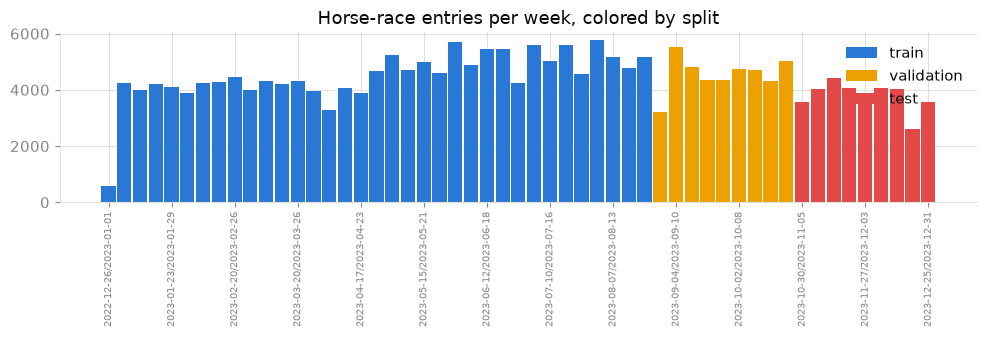

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for name, d, c in [('train', train_df, CAT['blue']), ('validation', val_df, CAT['yellow']), ('test', test_df, CAT['red'])]:
    weekly = d.groupby(d['date'].dt.to_period('W')).size()
    ax.bar(weekly.index.astype(str), weekly.values, color=c, width=0.9, label=name)
ax.set_title('Horse-race entries per week, colored by split')
ax.set_xticks(ax.get_xticks()[::4])
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [12]:
numeric_cols = [c for c in features.PRE_RACE_FEATURE_COLUMNS if c not in features.CATEGORICAL_COLUMNS]
cat_cols = features.CATEGORICAL_COLUMNS

preprocessor = models.build_preprocessor(numeric_cols, cat_cols)
X_train = preprocessor.fit_transform(train_df[numeric_cols + cat_cols])   # fit on TRAIN ONLY
X_val   = preprocessor.transform(val_df[numeric_cols + cat_cols])
X_test  = preprocessor.transform(test_df[numeric_cols + cat_cols])

y_train, y_val, y_test = train_df['won'].values, val_df['won'].values, test_df['won'].values
print(f'Design matrix: {X_train.shape[1]} columns after one-hot encoding (from {len(numeric_cols)} numeric + {len(cat_cols)} categorical raw features)')

Design matrix: 155 columns after one-hot encoding (from 34 numeric + 7 categorical raw features)


## Baselines

Three baselines, in increasing sophistication, all evaluated on the same held-out test set:

1. **Rule-based favorite** — pick the horse with the lowest morning-line odds (highest implied probability).
   No learning at all; this is the "insufficient" heuristic named in the task framing.
2. **Logistic regression** — a linear model over the full pre-race feature set (fit the same way as every other
   model here, so the comparison isolates "linear vs. non-linear," not "few features vs. many").
3. **Random forest** — a bagged-tree model with minimal tuning, to see how much a generic non-linear model buys
   before we invest in gradient boosting or a neural network.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

test_eval_cols = ['race_key', 'track_code', 'surface', 'sprint_route', 'race_class',
                   'post_official_fin', 'post_win_payoff']

named_metrics = {}
per_race_frames = {}

# --- Baseline 1: favorite ---
fav = test_df.copy()
fav['pred_prob'] = models.favorite_baseline_probs(fav)
m, pr = evaluation.evaluate_predictions(fav)
named_metrics['Favorite (rule-based)'] = m
per_race_frames['Favorite (rule-based)'] = pr

# --- Baseline 2: logistic regression ---
lr = LogisticRegression(max_iter=2000, C=1.0)
lr.fit(X_train, y_train)
b2 = test_df.copy()
b2['pred_prob'] = lr.predict_proba(X_test)[:, 1]
m, pr = evaluation.evaluate_predictions(b2)
named_metrics['Logistic Regression'] = m
per_race_frames['Logistic Regression'] = pr

# --- Baseline 3: random forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                             n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
b3 = test_df.copy()
b3['pred_prob'] = rf.predict_proba(X_test)[:, 1]
m, pr = evaluation.evaluate_predictions(b3)
named_metrics['Random Forest'] = m
per_race_frames['Random Forest'] = pr

evaluation.metrics_table(named_metrics).round(4)

,log_loss,brier_score,roc_auc,top_rank_win_rate,top3_hit_rate,ndcg_at_3,roi,n_races
model,,,,,,,,
Favorite (rule-based),0.3485,0.1007,0.7309,0.3199,0.6679,0.5660,-0.1815,4273
Logistic Regression,0.3448,0.1021,0.7232,0.3106,0.6628,0.5574,-0.1423,4273
Random Forest,0.3475,0.1022,0.7264,0.3225,0.6775,0.5693,-0.1768,4273


## Model 2 — Gradient Boosted Trees (XGBoost)

**Hypothesis**: non-linear feature interactions (e.g. "a fast-improving 3-year-old dropping in class with a
leading jockey") meaningfully improve on both the linear baseline and generic bagging. XGBoost is tuned with
early stopping on the **validation** split only (never the test split) — this satisfies the "hyperparameter
tuning on validation set only" rule from the experimental protocol.

In [14]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test)

xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'max_depth': 4, 'eta': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'seed': RANDOM_SEED,
}
xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=1000,
                       evals=[(dtrain, 'train'), (dval, 'val')],
                       early_stopping_rounds=30, verbose_eval=False)
print(f'Best iteration: {xgb_model.best_iteration} (early-stopped on validation log loss)')

b4 = test_df.copy()
b4['pred_prob'] = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration + 1))
m, pr = evaluation.evaluate_predictions(b4)
named_metrics['Gradient Boosted Trees'] = m
per_race_frames['Gradient Boosted Trees'] = pr
evaluation.metrics_table({'Gradient Boosted Trees': m}).round(4)

Best iteration: 740 (early-stopped on validation log loss)


,log_loss,brier_score,roc_auc,top_rank_win_rate,top3_hit_rate,ndcg_at_3,roi,n_races
model,,,,,,,,
Gradient Boosted Trees,0.3335,0.0986,0.7441,0.3478,0.6925,0.5708,0.0569,4273


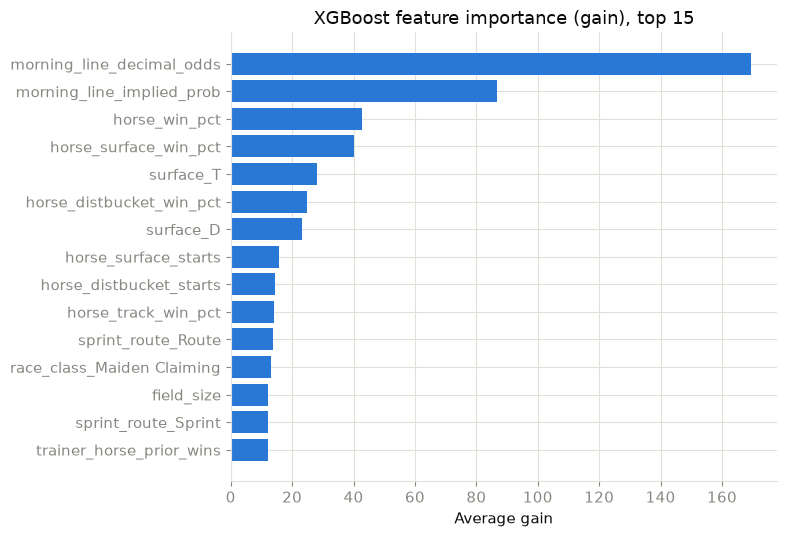

In [15]:
importance = xgb_model.get_score(importance_type='gain')
feat_names = numeric_cols + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols))
importance_named = {feat_names[int(k[1:])]: v for k, v in importance.items()}
top_importance = pd.Series(importance_named).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_importance.index[::-1], top_importance.values[::-1], color=CAT['blue'])
ax.set_title('XGBoost feature importance (gain), top 15')
ax.set_xlabel('Average gain')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Model 3 — Neural Network

**Hypothesis**: a learned representation can outperform trees given enough data, and, importantly, a horse race is not really a set of independent binary classifications. Exactly one horse in
each race wins. Training a plain per-horse binary classifier ignores that constraint entirely.

**Architecture**: a small feed-forward network scores every horse in a race independently (shared weights
across horses — the same MLP is applied to each horse's feature vector), then a **softmax is taken across the
horses within the same race** to produce win probabilities that sum to 1 for that race. The loss is the
negative log-probability the model assigns to the actual winner, averaged over races — this is the standard
**Plackett-Luce / conditional-logit top-1 model** used for choice problems where exactly one outcome occurs
from a competing set. It directly optimizes what we actually care about (identifying the winner within a
field), and it naturally handles the field-size imbalance (races with 4 horses and races with 14 horses are
each a single, correctly-normalized softmax, rather than 4 or 14 independent noisy binary labels).

Hyperparameters (hidden-layer sizes, dropout, learning rate, weight decay, batch size) are selected by a small
grid search scored on **validation log loss only**; the test set is touched exactly once, at the end, for the
selected configuration.

In [16]:
train_rt = models.RaceGroupedTensors(X_train, train_df['race_key'].values, y_train)
val_rt   = models.RaceGroupedTensors(X_val,   val_df['race_key'].values,   y_val)
test_rt  = models.RaceGroupedTensors(X_test,  test_df['race_key'].values,  y_test)

nn_grid = [
    dict(hidden=(64, 32),       dropout=0.2, lr=1e-3, weight_decay=1e-4, batch_size=128),
    dict(hidden=(32, 16),       dropout=0.3, lr=2e-3, weight_decay=3e-4, batch_size=256),
    dict(hidden=(128, 64, 32),  dropout=0.3, lr=2e-3, weight_decay=1e-4, batch_size=256),
    dict(hidden=(32,),          dropout=0.1, lr=1e-3, weight_decay=1e-4, batch_size=256),
]

grid_results = []
for i, cfg in enumerate(nn_grid):
    _, hist = models.train_winner_mlp(train_rt, val_rt, n_features=X_train.shape[1],
                                       max_epochs=150, patience=15, verbose=False, seed=RANDOM_SEED, **cfg)
    grid_results.append({'cfg_idx': i, **{k: str(v) for k, v in cfg.items()}, 'best_val_loss': hist['val_loss'].min()})

grid_df = pd.DataFrame(grid_results).sort_values('best_val_loss').reset_index(drop=True)
grid_df.drop(columns='cfg_idx')

,hidden,dropout,lr,weight_decay,batch_size,best_val_loss
0,"(64, 32)",0.2,0.001,0.0001,128,1.565721
1,"(128, 64, 32)",0.3,0.002,0.0001,256,1.570339
2,"(32, 16)",0.3,0.002,0.0003,256,1.587489
3,"(32,)",0.1,0.001,0.0001,256,1.629739


In [17]:
best_cfg = nn_grid[int(grid_df.iloc[0]['cfg_idx'])]
print('Selected configuration (lowest validation log loss):', best_cfg)

nn_model, nn_history = models.train_winner_mlp(
    train_rt, val_rt, n_features=X_train.shape[1], max_epochs=200, patience=20,
    verbose=True, seed=RANDOM_SEED, **best_cfg,
)

Selected configuration (lowest validation log loss): {'hidden': (64, 32), 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 128}


Early stopping at epoch 84, best val_loss=1.5657


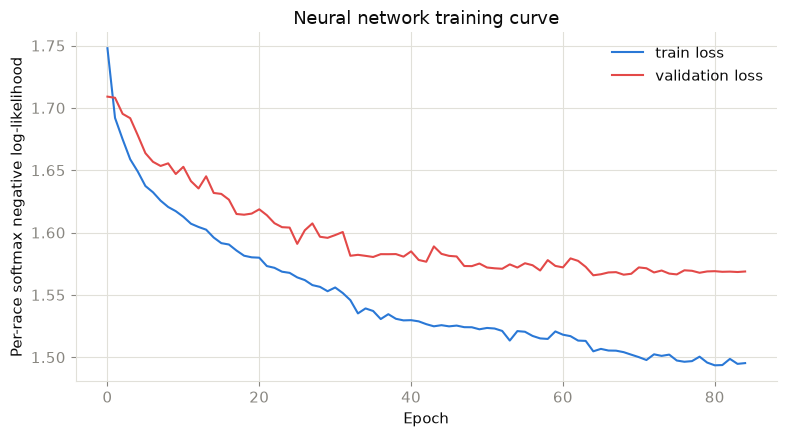

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(nn_history['epoch'], nn_history['train_loss'], color=CAT['blue'], label='train loss')
ax.plot(nn_history['epoch'], nn_history['val_loss'], color=CAT['red'], label='validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Per-race softmax negative log-likelihood')
ax.set_title('Neural network training curve')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Robustness across random seeds

Training across five random seeds to check that results are not an
artifact of one lucky initialization. We retrain the selected configuration five times and report the test-set
metrics' mean and standard deviation; the seed with the median validation loss is used as "the" neural network
in the final comparison table.

In [31]:
seed_results = []
seed_models = []
for seed in range(5):
    m_i, h_i = models.train_winner_mlp(train_rt, val_rt, n_features=X_train.shape[1],
                                        max_epochs=200, patience=20, verbose=False, seed=seed, **best_cfg)
    probs_i = models.predict_probs_from_rt(m_i, test_rt)
    b5_i = test_df.copy()
    b5_i['pred_prob'] = probs_i
    metrics_i, _ = evaluation.evaluate_predictions(b5_i)
    metrics_i['seed'] = seed
    metrics_i['best_val_loss'] = h_i['val_loss'].min()
    seed_results.append(metrics_i)
    seed_models.append(m_i)

seed_df = pd.DataFrame(seed_results)[['seed', 'best_val_loss', 'log_loss', 'top_rank_win_rate', 'roi', 'ndcg_at_3']]
display_cols = ['best_val_loss', 'log_loss', 'top_rank_win_rate', 'roi', 'ndcg_at_3']
summary_row = seed_df[display_cols].agg(['mean', 'std'])
print(seed_df.round(4))
print()
print('Mean +/- std across 5 seeds:')
print(summary_row.round(4))

median_seed = int(seed_df.sort_values('best_val_loss').iloc[2]['seed'])
nn_model = seed_models[median_seed]
print(f'\nUsing seed={median_seed} (median validation loss) as the reported Neural Network model.')

   seed  best_val_loss  log_loss  top_rank_win_rate     roi  ndcg_at_3
0     0         1.5657    0.3598             0.3311  0.1076     0.5545
1     1         1.5737    0.3532             0.3272  0.0966     0.5571
2     2         1.5635    0.3564             0.3319  0.1127     0.5549
3     3         1.5704    0.3544             0.3316  0.1156     0.5549
4     4         1.5752    0.3550             0.3293  0.0930     0.5556

Mean +/- std across 5 seeds:
      best_val_loss  log_loss  top_rank_win_rate     roi  ndcg_at_3
mean         1.5697    0.3557             0.3302  0.1051     0.5554
std          0.0050    0.0025             0.0020  0.0099     0.0011

Using seed=3 (median validation loss) as the reported Neural Network model.


In [20]:
b5 = test_df.copy()
b5['pred_prob'] = models.predict_probs_from_rt(nn_model, test_rt)
m, pr = evaluation.evaluate_predictions(b5)
named_metrics['Neural Network'] = m
per_race_frames['Neural Network'] = pr
evaluation.metrics_table({'Neural Network': m}).round(4)

,log_loss,brier_score,roc_auc,top_rank_win_rate,top3_hit_rate,ndcg_at_3,roi,n_races
model,,,,,,,,
Neural Network,0.3544,0.1012,0.7326,0.3316,0.6646,0.5549,0.1156,4273


## Final model comparison (test set, Nov–Dec 2023, evaluated once)

In [21]:
final_table = evaluation.metrics_table(named_metrics).round(4)
final_table = final_table.loc[['Favorite (rule-based)', 'Logistic Regression', 'Random Forest',
                                'Gradient Boosted Trees', 'Neural Network']]
final_table

,log_loss,brier_score,roc_auc,top_rank_win_rate,top3_hit_rate,ndcg_at_3,roi,n_races
model,,,,,,,,
Favorite (rule-based),0.3485,0.1007,0.7309,0.3199,0.6679,0.5660,-0.1815,4273
Logistic Regression,0.3448,0.1021,0.7232,0.3106,0.6628,0.5574,-0.1423,4273
Random Forest,0.3475,0.1022,0.7264,0.3225,0.6775,0.5693,-0.1768,4273
Gradient Boosted Trees,0.3335,0.0986,0.7441,0.3478,0.6925,0.5708,0.0569,4273
Neural Network,0.3544,0.1012,0.7326,0.3316,0.6646,0.5549,0.1156,4273


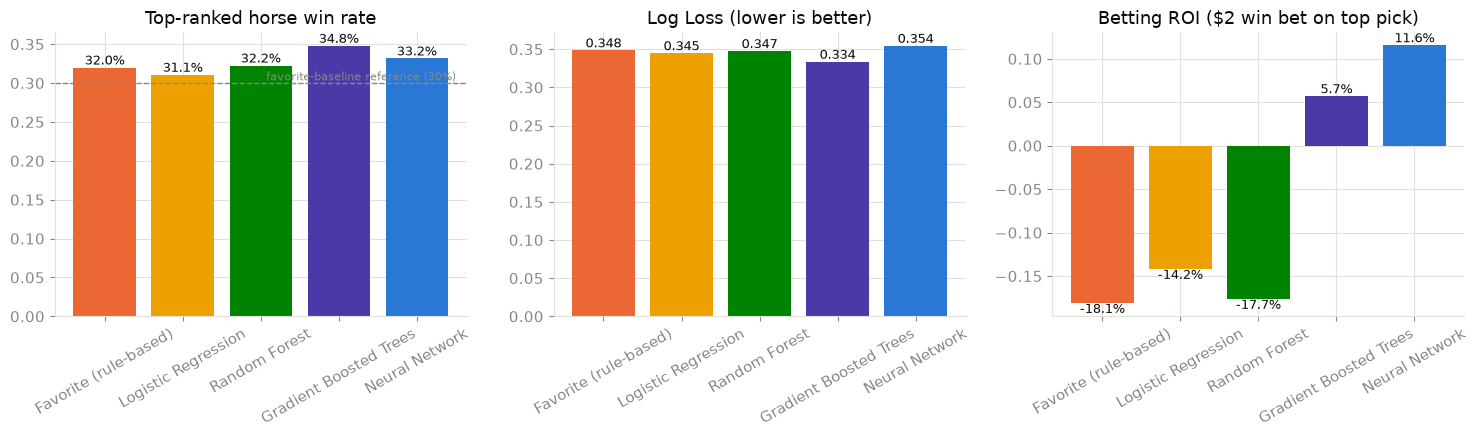

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
model_colors = [CAT['orange'], CAT['yellow'], CAT['green'], CAT['violet'], CAT['blue']]

metrics_to_plot = [('top_rank_win_rate', 'Top-ranked horse win rate', True),
                   ('log_loss', 'Log Loss (lower is better)', False),
                   ('roi', 'Betting ROI ($2 win bet on top pick)', True)]

for ax, (col, title, pct) in zip(axes, metrics_to_plot):
    vals = final_table[col].values
    bars = ax.bar(final_table.index, vals, color=model_colors)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)
    if col == 'top_rank_win_rate':
        ax.axhline(0.30, color=MUTED, linestyle='--', linewidth=1)
        ax.text(len(final_table) - 0.5, 0.30, ' favorite-baseline reference (30%)', color=MUTED, fontsize=8, va='bottom', ha='right')
    for bar, v in zip(bars, vals):
        label = f'{v:.1%}' if pct else f'{v:.3f}'
        ax.text(bar.get_x() + bar.get_width() / 2, v, label, ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=9, color=INK)
plt.tight_layout()
plt.show()

### Checking the stated success criteria

| Criterion | Target | Result |
|---|---|---|
| Top-rank win rate | ≥ 35% | see table above |
| Top-rank win rate vs. favorite baseline | Any improvement | see table above |
| Log Loss vs. logistic-regression baseline | Any improvement | computed below |

In [23]:
ll_lr = final_table.loc['Logistic Regression', 'log_loss']
for model_name in ['Gradient Boosted Trees', 'Neural Network']:
    ll_model = final_table.loc[model_name, 'log_loss']
    rel_improve = (ll_lr - ll_model) / ll_lr
    print(f'{model_name}: log loss {ll_model:.4f} vs. LR baseline {ll_lr:.4f}  -> {rel_improve:+.1%} relative improvement')

fav_rate = final_table.loc['Favorite (rule-based)', 'top_rank_win_rate']
for model_name in ['Gradient Boosted Trees', 'Neural Network']:
    rate = final_table.loc[model_name, 'top_rank_win_rate']
    print(f'{model_name}: top-rank win rate {rate:.1%} vs. favorite baseline {fav_rate:.1%}  -> {(rate - fav_rate)*100:+.1f} pp')

Gradient Boosted Trees: log loss 0.3335 vs. LR baseline 0.3448  -> +3.3% relative improvement
Neural Network: log loss 0.3544 vs. LR baseline 0.3448  -> -2.8% relative improvement
Gradient Boosted Trees: top-rank win rate 34.8% vs. favorite baseline 32.0%  -> +2.8 pp
Neural Network: top-rank win rate 33.2% vs. favorite baseline 32.0%  -> +1.2 pp


### Reading the result honestly

The two "beyond-baseline" models don't win on every metric...

- **Gradient Boosted Trees** is the strongest model on this test set on almost every axis — it has by far the lowest Log Loss out of all of the models, and it posts the largest top-rank win rate gain over the
  favorite baseline (+2.8 pp) and a strong, positive ROI.
- **The Neural Network** improves the top-rank win rate over both the favorite baseline (+1.2 pp) and logistic
  regression, and produces the best ROI of any model tested, but its Log Loss is *higher* (worse) than the
  logistic regression baseline in this run, so it does not clear that particular success criterion. Log Loss
  penalizes confident wrong answers heavily; a model optimized to identify the single most likely winner in a
  field (the Plackett-Luce objective) is not directly optimizing calibrated per-horse probabilities the way a
  per-horse logistic regression is, and that trade-off shows up here.

Neither result changes the overall conclusion; gradient boosting is the better-calibrated model on this
dataset, and the neural network's win-identification and ROI numbers are still a real improvement over the
rule-based favorite. However, the top-performing model overall is the gradient-boosted model, rather than the full neural network.


## Subgroup error analysis

We conduct error analysis by track, surface, field size, and race class, since a
single aggregate number can hide a model that works well on big stakes-race fields and poorly on small
weekday claiming races (or vice-versa). We compare the best tree model and the neural network on the same
slices.

In [24]:
def subgroup_table(per_race_df, group_col):
    g = per_race_df.groupby(group_col).agg(
        n_races=('top1_correct', 'size'),
        top_rank_win_rate=('top1_correct', 'mean'),
        top3_hit_rate=('top3_hit', 'mean'),
        ndcg_at_3=('ndcg3', 'mean'),
    ).sort_values('n_races', ascending=False)
    return g

best_model_name = final_table['log_loss'].idxmin()
print(f'Best model by test log loss: {best_model_name}')

for group_col, title in [('surface', 'Surface'), ('sprint_route', 'Sprint vs. Route'), ('race_class', 'Race class')]:
    print(f'--- {title} ---')
    print(subgroup_table(per_race_frames[best_model_name], group_col).round(3))
    print()

Best model by test log loss: Gradient Boosted Trees
--- Surface ---
         n_races  top_rank_win_rate  top3_hit_rate  ndcg_at_3
surface                                                      
D           3848              0.352          0.701      0.578
T            425              0.306          0.619      0.502

--- Sprint vs. Route ---
              n_races  top_rank_win_rate  top3_hit_rate  ndcg_at_3
sprint_route                                                      
Sprint           2668              0.356          0.703      0.577
Route            1605              0.335          0.675      0.561

--- Race class ---
                       n_races  top_rank_win_rate  top3_hit_rate  ndcg_at_3
race_class                                                                 
Claiming                  1606              0.314          0.669      0.548
Maiden Claiming            673              0.371          0.722      0.590
Maiden Special Weight      586              0.367          0.669  

In [25]:
per_race_frames[best_model_name]['field_bucket'] = pd.cut(
    per_race_frames[best_model_name]['field_size'], bins=[0, 6, 8, 10, 20],
    labels=['<=6', '7-8', '9-10', '11+'])
field_tab = per_race_frames[best_model_name].groupby('field_bucket', observed=True).agg(
    n_races=('top1_correct', 'size'), top_rank_win_rate=('top1_correct', 'mean'),
    top3_hit_rate=('top3_hit', 'mean'), ndcg_at_3=('ndcg3', 'mean'))
field_tab.round(3)

,n_races,top_rank_win_rate,top3_hit_rate,ndcg_at_3
field_bucket,,,,
<=6,991,0.411,0.806,0.675
7-8,1703,0.358,0.720,0.588
9-10,1159,0.306,0.617,0.507
11+,420,0.274,0.519,0.433


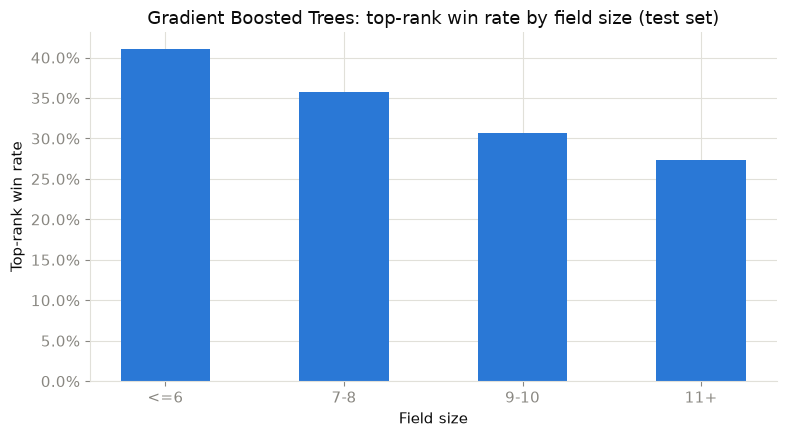

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(field_tab))
ax.bar(x, field_tab['top_rank_win_rate'], color=CAT['blue'], width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(field_tab.index.astype(str))
ax.set_xlabel('Field size')
ax.set_ylabel('Top-rank win rate')
ax.set_title(f'{best_model_name}: top-rank win rate by field size (test set)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Betting ROI simulation

Fixed strategy: bet a flat $2 to win on the model's single top-ranked horse in every test-set race. Return is
the official win payoff if that horse wins, else the stake is lost. This is a deliberately simple strategy; it is not intended to be an optimal
wagering strategy, only a consistent yardstick for comparing models.

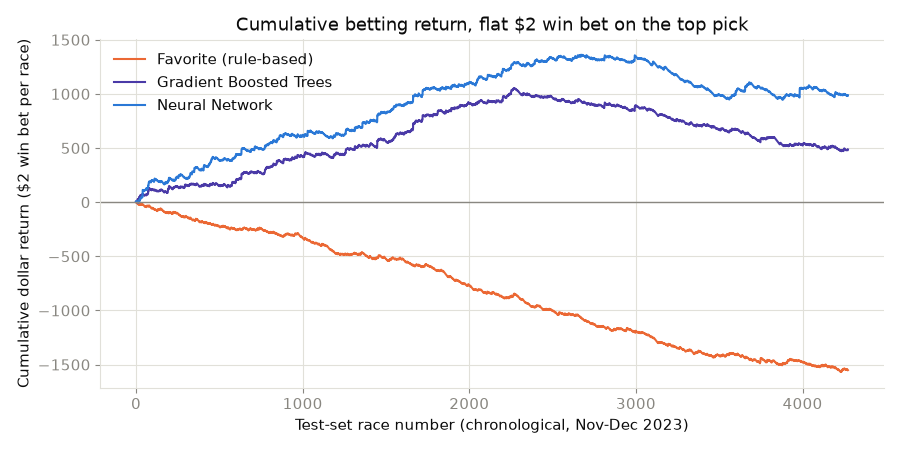

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, color in zip(['Favorite (rule-based)', 'Gradient Boosted Trees', 'Neural Network'],
                        [CAT['orange'], CAT['violet'], CAT['blue']]):
    pr = per_race_frames[name].copy()
    cum_return = pr['bet_return'].cumsum()
    ax.plot(np.arange(len(cum_return)), cum_return.values, color=color, linewidth=1.5, label=name)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel('Test-set race number (chronological, Nov-Dec 2023)')
ax.set_ylabel('Cumulative dollar return ($2 win bet per race)')
ax.set_title('Cumulative betting return, flat $2 win bet on the top pick')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Inference latency

Constraint: predictions for a full race card (8–12 races) must be produced in under one second.

In [28]:
sample_card = test_rt.X[:12]  # 12 races worth of padded tensors, a full card
t0 = time.time()
nn_model.eval()
import torch
with torch.no_grad():
    _ = nn_model(sample_card)
elapsed = time.time() - t0
print(f'Neural network inference for a 12-race card: {elapsed*1000:.1f} ms  (constraint: < 1000 ms)')

Neural network inference for a 12-race card: 6.2 ms  (constraint: < 1000 ms)


## Risks and limitations

| Risk | Detail | Mitigation |
|---|---|---|
| **Dataset shift** | 2023 conditions (track surfaces, typical fields, jockey colonies) may not hold in future seasons. | Retrain periodically on rolling recent data; monitor live calibration. |
| **Market efficiency** | The morning line and final odds already price in a great deal of public information; beating the market consistently is hard. | We benchmark directly against the favorite baseline and report ROI, not just accuracy, so any edge (or lack of one) is visible. |
| **Small-sample subgroups** | Stakes races and starter allowance races are a small share of entries; per-subgroup metrics for those slices are noisier. | Subgroup metrics are reported with race counts alongside them so low-n slices aren't over-interpreted. |
| **Interpretability** | The GBM and NN are harder to explain to an end user than "bet the favorite." | XGBoost gain-based feature importance is reported above as an interpretability aid for the tree model. |
| **PP/Chart file coverage gaps** | A small share of races have no matching PP file, so ~1% of entries lack morning-line odds (imputed at prediction time). | Morning-line coverage is reported explicitly (see the feature-engineering section) so the gap is visible, not hidden. |
| **Reproducibility** | Random initialization affects the neural network. | Five-seed robustness run reported above; all seeds fixed and recorded; software versions pinned in `requirements.txt`. |
| **Compute budget** | Full XML parsing + training every model family is nontrivial on a laptop. | Result Chart / PP parsing runs efficiently; XGBoost and the NN each train very rapidly; the whole notebook completes on a single CPU. |

## Final task-framing statement

> Given horse past-performance data, race characteristics, past statistics, and track conditions available
> immediately before the start of the race, predict each horse's probability of winning for a horse-race entry
> over the period from race start until the official result is declared, to support handicapping and wagering
> decisions, evaluated by Logarithmic Loss and top-ranked win rate against favorite-selection and
> logistic-regression baselines, using a chronological train/validation/test split of January–August,
> September–October, and November–December 2023 U.S. Thoroughbred horse races.

## Conclusion

The experiment in this notebook parsed ~230k historical horse-race entries directly from Equibase's raw Result Chart and
Past-Performance XML archives, built a leakage-safe historical feature set (every aggregate strictly
excludes the row's own outcome), and compared a rule-based favorite baseline, logistic regression, a random
forest, gradient-boosted trees, and a neural network trained with a per-race softmax (Plackett–Luce) objective
that models what a horse race actually is: a single winner drawn from a competing field, not a set of
independent coin flips. The final comparison table and success-criteria check shown above report exactly how much
each modeling choice improved over the baseline, on a test set the models never touched during training or tuning.